# Práctica 2: Determinación de tipos de estrellas

## 0. Introducción

En esta práctica se aborda un problema de aprendizaje no supervisado aplicado al ámbito de la astronomía. El objetivo es identificar agrupaciones naturales de estrellas a partir de sus características físicas y espectrales, sin disponer de etiquetas previas.

El conjunto de datos contiene 240 estrellas descritas mediante las variables:
- `Temperature`: temperatura superficial media en Kelvin.
- `L`: luminosidad relativa respecto al Sol.
- `R`: radio relativo respecto al Sol.
- `A_M`: magnitud absoluta.
- `Spectral_Class`: clase espectral.
- `Color`: color principal del espectro.

El propósito final de la práctica será comparar distintos algoritmos de clustering y analizar si los grupos encontrados presentan similitudes con las clases estelares utilizadas en astronomía.

Realizado por Diego Valladares Ortega - 100475849

## 0.1 Imports necesarios

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from hdbscan.validity import validity_index

import warnings
warnings.filterwarnings("ignore")

SEED = 100475849
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

En este apartado se importan las librerías necesarias para el análisis exploratorio, la visualización, el preprocesado y los algoritmos de clustering que se utilizarán más adelante. Se usa `hdbscan.validity.validity_index` para calcular la métrica DBCV requerida por el enunciado para evaluar DBSCAN. Se fija una semilla para garantizar la reproducibilidad.

## 1. EDA

### 1.1 Carga del conjunto de datos y primera inspección

El primer paso del análisis exploratorio consiste en cargar el conjunto de datos y examinar su estructura general. Esto permite comprobar el número de observaciones, las variables disponibles y el formato en el que se encuentran almacenadas.

Esta revisión inicial es importante porque ayuda a detectar problemas tempranos, como nombres de columnas inconsistentes, tipos de datos incorrectos o posibles valores anómalos.

In [2]:
df = pd.read_csv("data/stars_data.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())
display(df.sample(5, random_state=SEED))

Dimensiones del dataset: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


,Temperature,L,R,A_M,Color,Spectral_Class
70,3345,0.021000,0.2730,12.30,Red,M
73,3150,0.008800,0.3500,11.94,Red,M
232,32489,648430.000000,1948.5000,-10.84,Blue,O
111,3605,126000.000000,1124.0000,-10.81,Red,M
128,2856,0.000896,0.0782,19.56,Red,M


**Conclusión**: El dataset contiene 240 estrellas y 6 variables, combinando atributos numéricos y categóricos. La carga se ha realizado correctamente y, a simple vista, ya se observan estrellas con características muy diferentes, lo que hace razonable esperar la existencia de varios grupos en los datos.

### 1.2 Estructura de variables y calidad básica de los datos

A continuación se analizan los tipos de datos de cada variable, la presencia de valores nulos y la posible existencia de duplicados. Este paso es fundamental, ya que cualquier problema de calidad de datos puede afectar tanto al preprocesado como al rendimiento de los algoritmos de clustering.

In [3]:
display(df.info())

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nNúmero de duplicados:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


None


Valores nulos por columna:


,nulos
Temperature,0
L,0
R,0
A_M,0
Color,0
Spectral_Class,0



Número de duplicados: 0


**Conclusión**: Podemos observar que no hay valores nulos y del mismo modo tampoco tenemos columnas duplicadas.

### 1.3 Análisis descriptivo de variables numéricas

Se estudian las variables numéricas mediante estadísticos descriptivos como la media, la desviación típica, los cuartiles y los valores extremos. Este análisis permite entender la escala de cada variable y detectar posibles asimetrías o valores atípicos.

Este paso es especialmente relevante en esta práctica porque posteriormente se aplicará PCA y clustering, técnicas sensibles a las diferencias de escala entre variables.

In [4]:
num_cols = ["Temperature", "L", "R", "A_M"]

display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temperature,240.0,10497.462500,9552.425037,1939.00000,3344.250000,5776.0000,15055.5000,40000.00
L,240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
R,240.0,237.157781,517.155763,0.00840,0.102750,0.7625,42.7500,1948.50
A_M,240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06


**Conclusión**: Los estadísticos descriptivos muestran que las variables numéricas presentan escalas muy diferentes entre sí. Además, `L` y `R` parecen estar fuertemente sesgadas, con valores máximos muy alejados de la mediana, lo que sugiere la presencia de estrellas con características extremas. En conjunto, este análisis refuerza la necesidad de estandarizar los datos antes de aplicar PCA y los algoritmos de clustering.

### 1.4 Distribución de las variables numéricas

Una vez revisados los estadísticos descriptivos, se representan gráficamente las distribuciones de las variables numéricas. El objetivo es analizar su forma, detectar asimetrías y observar si existen concentraciones de valores o colas largas.

Este análisis resulta útil para anticipar si algunas variables podrían requerir transformaciones adicionales o una atención especial durante el preprocesado.

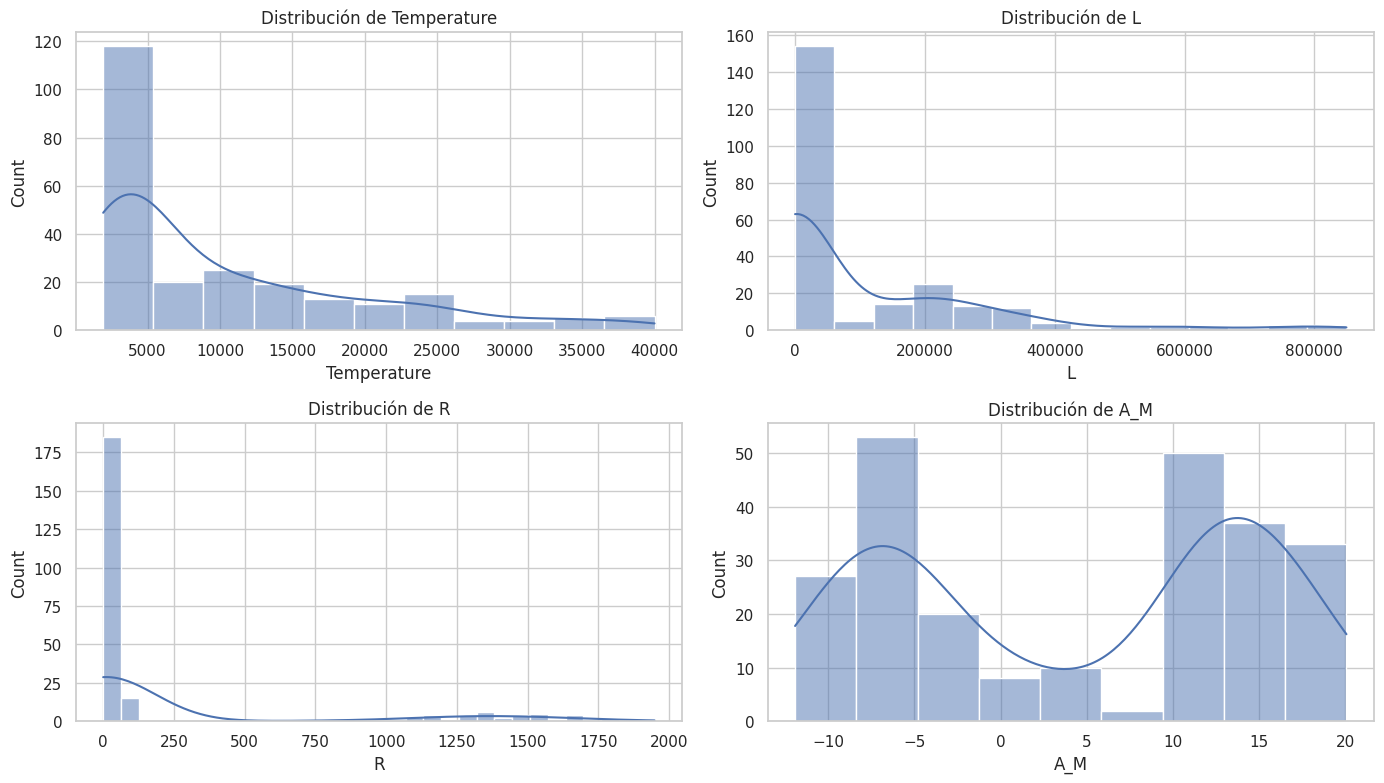

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: Las distribuciones de `Temperature`, `L` y `R` muestran una clara asimetría positiva, con gran concentración de estrellas en valores bajos y una cola larga hacia valores altos. Esto sugiere la existencia de observaciones extremas que podrían influir en el clustering. Por su parte, `A_M` presenta una distribución menos concentrada y parece reflejar varios grupos de estrellas con comportamientos distintos.

## 1.5 Detección visual de valores atípicos

Tras analizar la distribución de las variables numéricas, resulta útil estudiar la posible presencia de valores atípicos mediante diagramas de caja. Este análisis permite identificar observaciones extremas y valorar su impacto potencial en técnicas posteriores como PCA y clustering.

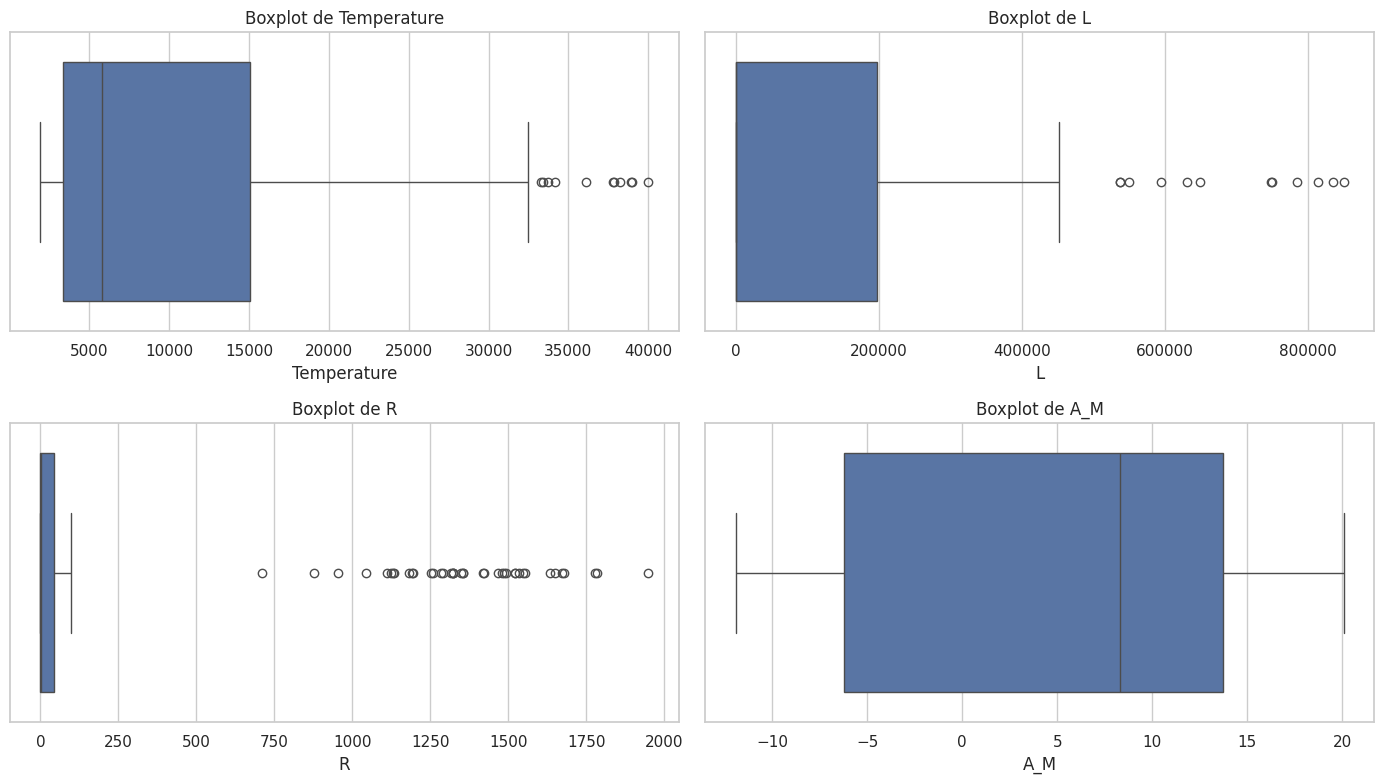

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: Los boxplots muestran la presencia de valores atípicos, especialmente en `L` y `R`, y en menor medida en `Temperature`. Esto indica que existen estrellas con características muy extremas respecto al resto del conjunto. En cambio, `A_M` presenta una distribución más estable. Dado el contexto del problema, estos valores extremos no deben considerarse necesariamente errores, sino posibles observaciones relevantes para la formación de grupos.

## 1.6 Análisis de variables categóricas

En este apartado se estudian las variables categóricas `Color` y `Spectral_Class`. El objetivo es conocer sus valores posibles, su frecuencia y detectar posibles inconsistencias en el etiquetado. Este paso es especialmente importante, ya que ambas variables deberán codificarse posteriormente de forma ordinal, respetando su relación con la energía.

In [7]:
cat_cols = ["Color", "Spectral_Class"]

for col in cat_cols:
    print(f"\nFrecuencias de {col}:")
    display(df[col].value_counts())
    print(f"Valores únicos en {col}: {df[col].nunique()}")


Frecuencias de Color:


Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

Valores únicos en Color: 17

Frecuencias de Spectral_Class:


Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

Valores únicos en Spectral_Class: 7


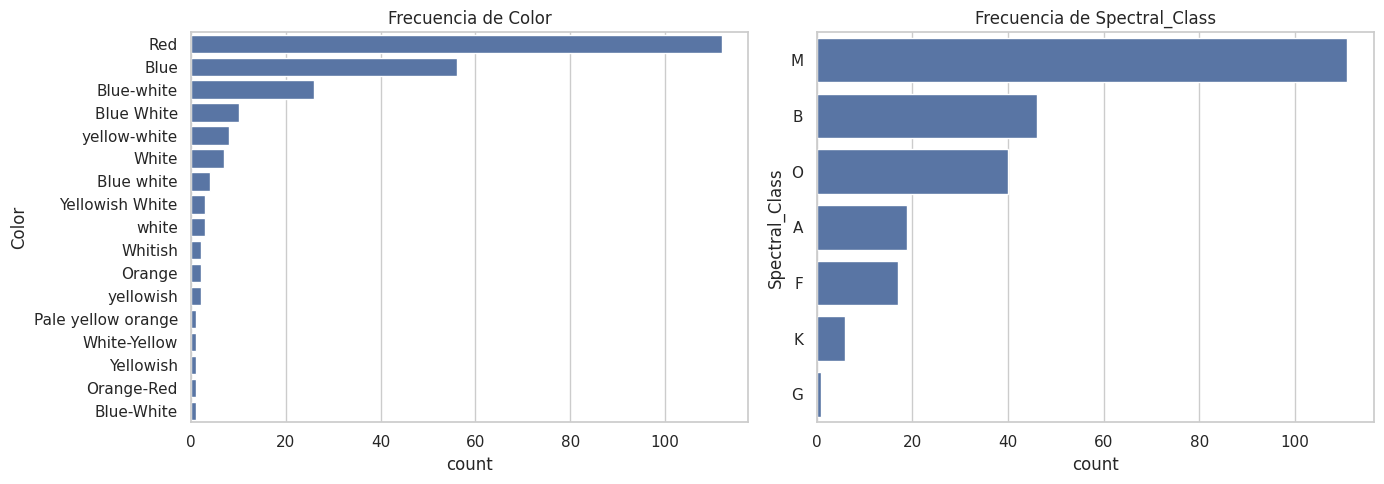

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Frecuencia de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: El análisis de las variables categóricas muestra que `Color` y `Spectral_Class` presentan un número reducido de categorías, aunque con una distribución desigual. En `Color` se observan además varias inconsistencias de escritura, como diferencias entre mayúsculas, espacios y guiones, por lo que será necesario unificar estas etiquetas antes de realizar la codificación ordinal. Por su parte, `Spectral_Class` presenta un claro predominio de algunas clases, especialmente `M`.

## 1.7 Relación entre variables numéricas

Una vez analizadas las distribuciones individuales, resulta útil estudiar la relación entre las variables numéricas mediante una matriz de correlación. Esto permite identificar dependencias lineales entre atributos y valorar si existe información redundante, algo relevante de cara a la aplicación posterior de PCA.

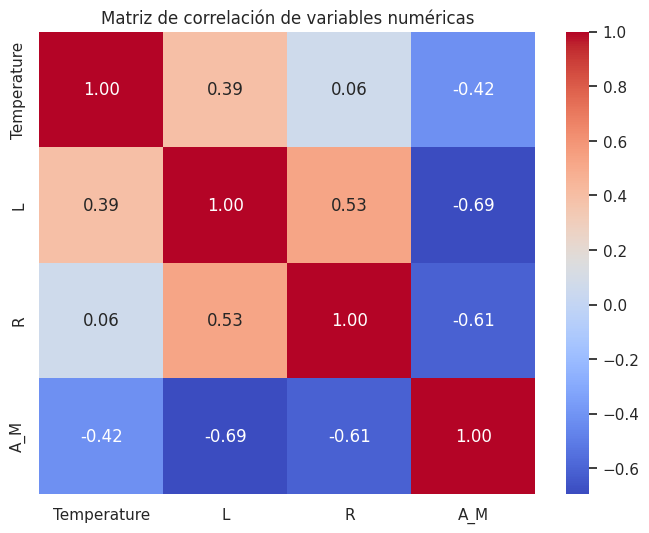

In [9]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

**Conclusión**: La matriz de correlación muestra que existen relaciones relevantes entre varias variables numéricas. En particular, `L` y `R` presentan una correlación positiva moderada, mientras que `A_M` se relaciona de forma negativa con ambas. Esto indica que parte de la información está compartida entre variables, lo que justifica el uso posterior de PCA para reducir dimensionalidad.

## 1.8 Conclusiones del EDA

- El dataset contiene 240 estrellas y 6 variables, sin valores nulos ni duplicados.
- Las variables numéricas presentan escalas muy diferentes, especialmente `L` y `R`.
- En `Temperature`, `L` y `R` se observan distribuciones asimétricas y valores extremos.
- `Color` y `Spectral_Class` son variables categóricas con significado ordinal, ya que están relacionadas con la energía de la estrella.
- En `Color` aparecen varias inconsistencias de escritura, por lo que será necesario unificar etiquetas antes de codificar.
- La correlación entre algunas variables numéricas justifica aplicar PCA para reducir dimensionalidad antes del clustering.
- En conjunto, el EDA confirma que el siguiente paso debe ser el preprocesado: limpieza de categorías, codificación ordinal, estandarización y PCA a 2 componentes.

## 2. Preprocesado de los datos

En este apartado se prepara el dataset para aplicar las técnicas de clustering. Para ello, primero se revisan y limpian las variables categóricas, después se realiza su codificación ordinal y, finalmente, se estandarizan los datos y se aplica PCA a 2 componentes principales.

### 2.1 Revisión de categorías

Antes de codificar las variables categóricas, se revisan sus valores únicos para detectar posibles inconsistencias en el etiquetado. Este paso es especialmente importante en `Color`, donde durante el EDA ya se observaron diferencias en mayúsculas, espacios y guiones.

In [10]:
print("Valores únicos de Color:")
print(sorted(df["Color"].unique()))

print("\nValores únicos de Spectral_Class:")
print(sorted(df["Spectral_Class"].unique()))

Valores únicos de Color:
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Valores únicos de Spectral_Class:
['A', 'B', 'F', 'G', 'K', 'M', 'O']


**Conclusión**: La revisión de valores únicos confirma que `Color` contiene varias etiquetas equivalentes escritas de forma distinta, por lo que será necesario unificarlas antes de la codificación. En cambio, `Spectral_Class` presenta categorías limpias y bien definidas.

### 2.2 Limpieza de la variable `Color`

Se unifican las distintas formas de escribir una misma categoría en la variable `Color`. De este modo, se evitan duplicidades artificiales y se asegura una codificación ordinal coherente.

In [11]:
df_clean = df.copy()

color_mapping = {
    "Red": "Red",
    "Orange-Red": "Orange-Red",
    "Orange": "Orange",
    "Pale yellow orange": "Pale Yellow Orange",
    "yellowish": "Yellowish",
    "Yellowish": "Yellowish",
    "yellow-white": "Yellow-White",
    "White-Yellow": "Yellow-White",
    "White": "White",
    "white": "White",
    "Whitish": "Whitish",
    "Yellowish White": "Yellowish White",
    "Blue-white": "Blue-White",
    "Blue white": "Blue-White",
    "Blue White": "Blue-White",
    "Blue-White": "Blue-White",
    "Blue": "Blue"
}

df_clean["Color"] = df_clean["Color"].str.strip().replace(color_mapping)

print("Valores únicos de Color tras la limpieza:")
print(sorted(df_clean["Color"].unique()))

Valores únicos de Color tras la limpieza:
['Blue', 'Blue-White', 'Orange', 'Orange-Red', 'Pale Yellow Orange', 'Red', 'White', 'Whitish', 'Yellow-White', 'Yellowish', 'Yellowish White']


**Conclusión**: Tras la limpieza, la variable `Color` queda formada por un conjunto de categorías más consistente y sin duplicidades debidas a diferencias de escritura. Esto permitirá aplicar una codificación ordinal más fiable.

### 2.3 Codificación ordinal de `Spectral_Class`

La variable `Spectral_Class` tiene carácter ordinal, ya que sigue una secuencia física asociada a la energía y temperatura de las estrellas. En astronomía, las clases espectrales se ordenan de las más frías a las más calientes como `M-K-G-F-A-B-O`, por lo que se realizará una codificación respetando dicho orden.

In [12]:
spectral_mapping = {
    "M": 0,
    "K": 1,
    "G": 2,
    "F": 3,
    "A": 4,
    "B": 5,
    "O": 6
}

df_clean["Spectral_Class_ord"] = df_clean["Spectral_Class"].map(spectral_mapping)

display(df_clean[["Spectral_Class", "Spectral_Class_ord"]].drop_duplicates().sort_values("Spectral_Class_ord"))
print("Valores nulos tras la codificación:", df_clean["Spectral_Class_ord"].isna().sum())

,Spectral_Class,Spectral_Class_ord
0,M,0
91,K,1
118,G,2
22,F,3
21,A,4
20,B,5
30,O,6


Valores nulos tras la codificación: 0


**Conclusión:** La variable `Spectral_Class` ha quedado transformada en una escala ordinal coherente con su significado físico, lo que permitirá incorporarla al análisis sin perder la información asociada al orden entre categorías.

### 2.4 Codificación ordinal de `Color`

Una vez unificadas las categorías de `Color`, se realiza su codificación ordinal para poder incorporar esta variable al análisis numérico. Aunque a simple vista pueda parecer una variable meramente descriptiva, en este contexto el color del espectro está relacionado con propiedades físicas de la estrella, como su energía o temperatura.

Por ello, no resulta adecuado tratar `Color` como una categoría cualquiera sin orden. En su lugar, se establece una progresión aproximada desde tonos rojizos, asociados a menor energía, hasta tonos azulados, asociados a mayor energía. De este modo, la variable puede utilizarse posteriormente en PCA y en los algoritmos de clustering conservando parte de su significado físico.

In [13]:
color_mapping_ord = {
    "Blue": 0,
    "Blue-White": 1,
    "White": 2,
    "Yellowish White": 3,
    "Whitish": 4,
    "Yellow-White": 5,
    "Yellowish": 6,
    "Pale Yellow Orange": 7,
    "Orange": 8,
    "Orange-Red": 9,
    "Red": 10
}

df_clean["Color_ord"] = df_clean["Color"].map(color_mapping_ord)

display(df_clean[["Color", "Color_ord"]].drop_duplicates().sort_values("Color_ord"))
print("Valores nulos tras la codificación:", df_clean["Color_ord"].isna().sum())

,Color,Color_ord
30,Blue,0
20,Blue-White,1
21,White,2
25,Yellowish White,3
33,Whitish,4
34,Yellow-White,5
91,Yellowish,6
29,Pale Yellow Orange,7
53,Orange,8
96,Orange-Red,9


Valores nulos tras la codificación: 0


**Conclusión:** La variable `Color` queda representada mediante una escala ordinal coherente con la progresión energética del espectro, lo que permite incorporarla al análisis numérico posterior.

### 2.5 Construcción del dataset final

Una vez codificadas las variables categóricas, se construye el conjunto de datos que se utilizará en las siguientes etapas del análisis. En este nuevo dataset se reúnen las variables numéricas originales junto con las versiones ordinales de `Color` y `Spectral_Class`, de modo que toda la información relevante quede representada de forma numérica.

In [14]:
features = ["Temperature", "L", "R", "A_M", "Color_ord", "Spectral_Class_ord"]

X = df_clean[features].copy()

display(X.head())
print("Dimensiones del dataset final:", X.shape)

,Temperature,L,R,A_M,Color_ord,Spectral_Class_ord
0,3068,0.002400,0.1700,16.12,10,0
1,3042,0.000500,0.1542,16.60,10,0
2,2600,0.000300,0.1020,18.70,10,0
3,2800,0.000200,0.1600,16.65,10,0
4,1939,0.000138,0.1030,20.06,10,0


Dimensiones del dataset final: (240, 6)


**Conclusión:** En este punto ya se dispone de un conjunto de datos completamente numérico, preparado para aplicar las transformaciones previas al clustering.

### 2.6 Estandarización de variables

Antes de aplicar PCA y los algoritmos de clustering, es necesario estandarizar las variables. Esto se debe a que no todas están medidas en la misma escala: por ejemplo, `Temperature`, `L` y `R` toman valores muy distintos respecto a las variables codificadas ordinalmente.

Si no se realizara esta transformación, las variables con mayor magnitud podrían dominar el análisis y condicionar en exceso la formación de los grupos. Por ello, se utiliza una estandarización que centra cada variable en media 0 y desviación típica 1.

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,Temperature,L,R,A_M,Color_ord,Spectral_Class_ord
0,-0.779382,-0.598624,-0.459210,1.116745,1.014108,-0.997781
1,-0.782110,-0.598624,-0.459241,1.162414,1.014108,-0.997781
2,-0.828477,-0.598624,-0.459342,1.362213,1.014108,-0.997781
3,-0.807496,-0.598624,-0.459229,1.167171,1.014108,-0.997781
4,-0.897819,-0.598624,-0.459340,1.491607,1.014108,-0.997781


**Conclusión**: Se usa `StandardScaler` para centrar y escalar cada variable a media 0 y desviación típica 1. Este paso es imprescindible tanto para PCA como para los algoritmos de clustering, ya que variables en distintas escalas distorsionan las distancias.

`X_scaled` será el espacio de características completo (6D) que usarán los modelos. A continuación se calculan también las dos componentes principales sobre las que se trabajará en paralelo.

### 2.7 Reducción de dimensionalidad mediante PCA

Para facilitar la visualización de los datos y aplicar posteriormente los algoritmos de clustering, se reduce el dataset a dos dimensiones mediante PCA. Esta transformación permite proyectar cada estrella en un espacio bidimensional conservando, en la medida de lo posible, la mayor cantidad de información del conjunto original.

In [17]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

display(df_pca.head())

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

,PC1,PC2
0,-2.070370,-0.146042
1,-2.089897,-0.163965
2,-2.191517,-0.234932
3,-2.103735,-0.160411
4,-2.275805,-0.272374


Varianza explicada por cada componente: [0.55431472 0.29696459]
Varianza explicada acumulada: 0.851279311117582


**Representacion grafica**

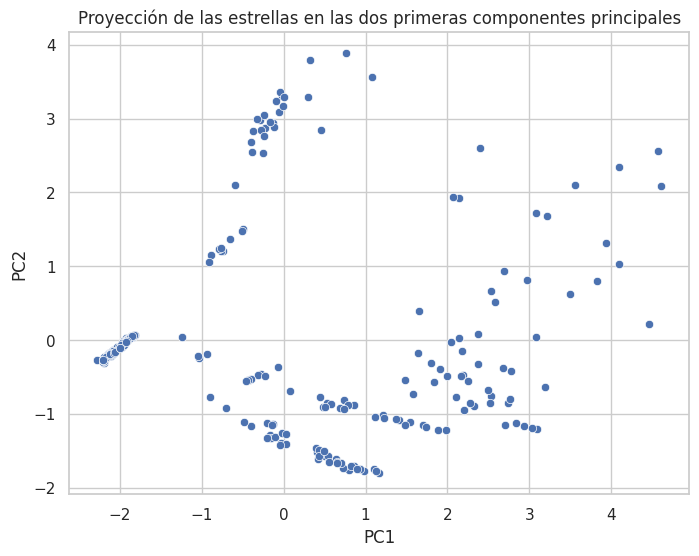

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2")
plt.title("Proyección de las estrellas en las dos primeras componentes principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Conclusión:** Las dos primeras componentes principales explican aproximadamente el 85% de la variabilidad total del dataset, por lo que la representación en dos dimensiones conserva una parte importante de la información original. Además, en la proyección se observan zonas diferenciadas, lo que sugiere que puede haber grupos naturales de estrellas.

### Conclusión del preprocesado
Tras limpiar la variable `Color`, codificar ordinalmente las variables categóricas, estandarizar las características y reducir la dimensionalidad a dos componentes principales, el conjunto de datos queda preparado para aplicar y comparar los distintos algoritmos de clustering.

### Nota sobre los dos espacios de características

En las secciones 3, 4 y 5 se aplicará cada algoritmo en **dos variantes**:

- **PCA** (`X_pca`): los algoritmos se ajustan sobre las 2 componentes principales. Esto es lo indicado en el enunciado como modo principal.
- **Variables originales** (`X_scaled`): los algoritmos se ajustan sobre las 6 variables estandarizadas. Esto permite estudiar si conservar toda la información mejora la calidad del clustering.

La comparación final se realizará en la sección 6.

## 3. K-Means

K-Means es un algoritmo de clustering que agrupa las observaciones en un número fijo de clusters. Para utilizarlo es necesario elegir previamente el valor de `k`, es decir, el número de grupos que queremos obtener.

### 3.1 Selección de k — sobre PCA

En este apartado se prueban distintos valores de `k` y se comparan mediante dos criterios: la inercia y el coeficiente de silhouette. La inercia mide la compactación de los clusters, mientras que silhouette permite evaluar si los puntos están bien asignados a su grupo.

In [22]:
k_values = range(2, 11)

inertias_pca, silhouettes_pca = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias_pca.append(km.inertia_)
    silhouettes_pca.append(silhouette_score(X_pca, labels))

kmeans_results_pca = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias_pca,
    "silhouette": silhouettes_pca
})

display(kmeans_results_pca)

,k,inertia,silhouette
0,2,603.445187,0.519116
1,3,334.212078,0.591750
2,4,169.433969,0.634718
3,5,105.288298,0.646905
4,6,81.519568,0.656079
5,7,63.304182,0.637676
6,8,54.205616,0.630307
7,9,47.603811,0.604135
8,10,42.529849,0.617263


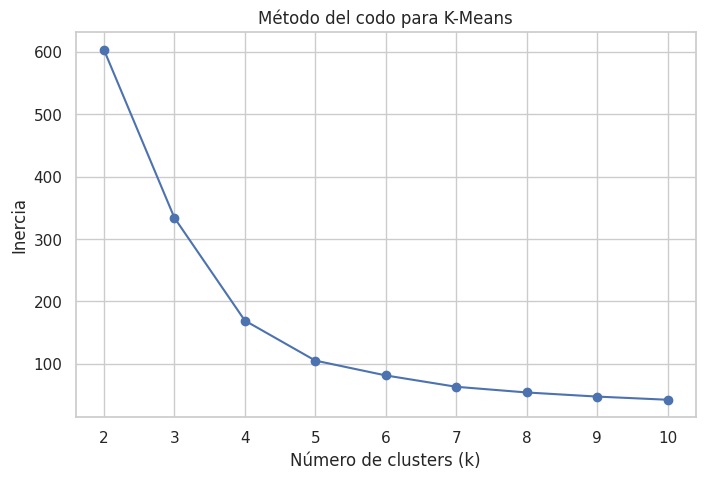

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.show()

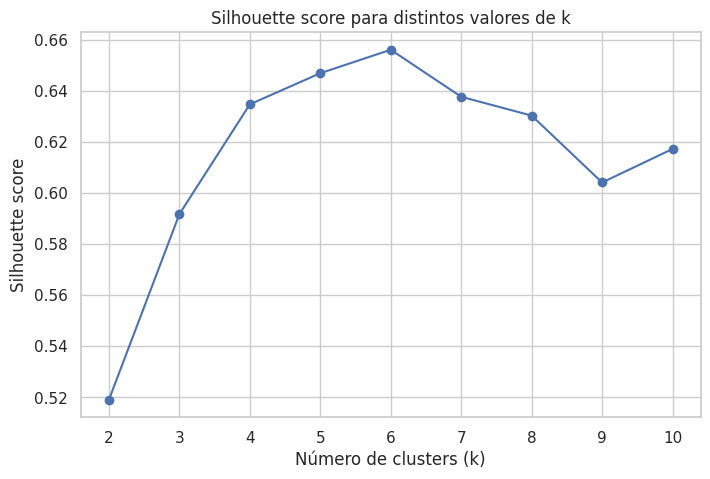

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
plt.title("Silhouette score para distintos valores de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.show()

**Conclusión:**  El método del codo muestra una reducción fuerte de la inercia hasta valores cercanos a `k = 5` o `k = 6`, a partir de los cuales la mejora empieza a ser menor. Por otro lado, el coeficiente silhouette alcanza su valor más alto para `k = 6`. Por este motivo, se selecciona `k = 6` como número de clusters para el modelo final de K-Means.

### 3.2 Selección de k — sobre variables originales

In [23]:
inertias_scaled, silhouettes_scaled = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias_scaled.append(km.inertia_)
    silhouettes_scaled.append(silhouette_score(X_scaled, labels))

kmeans_results_scaled = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias_scaled,
    "silhouette": silhouettes_scaled
})

display(kmeans_results_scaled)

,k,inertia,silhouette
0,2,815.258956,0.451406
1,3,534.123828,0.518788
2,4,350.601140,0.535912
3,5,270.332155,0.551658
4,6,226.208729,0.566848
5,7,187.735169,0.577449
6,8,158.421523,0.578819
7,9,135.497682,0.577751
8,10,119.977780,0.573435


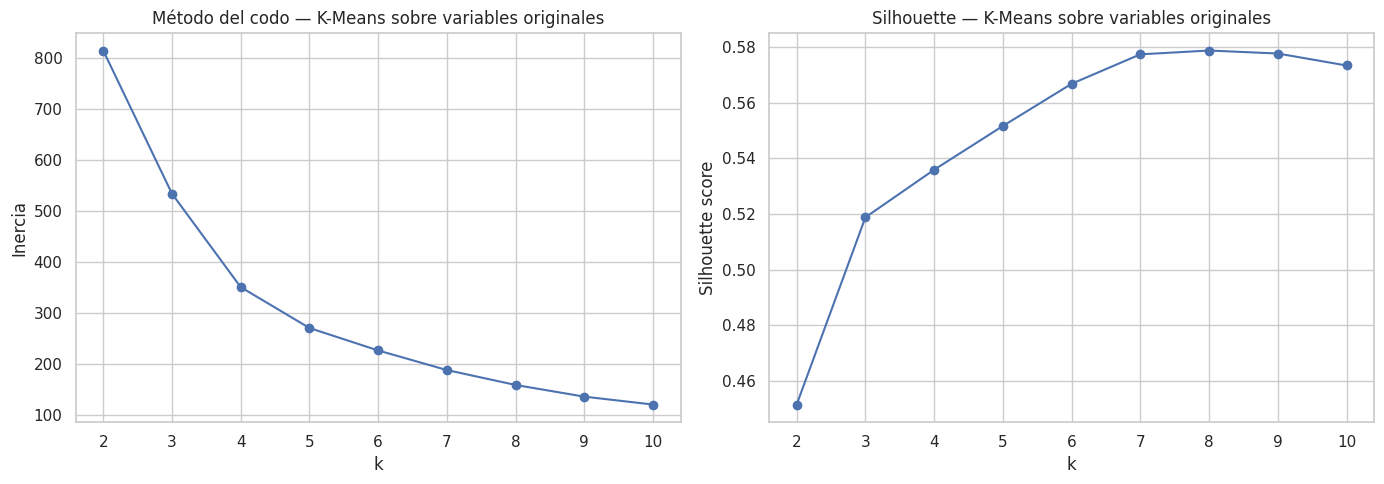

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_results_scaled["k"], kmeans_results_scaled["inertia"], marker="o")
axes[0].set_title("Método del codo — K-Means sobre variables originales")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")

axes[1].plot(kmeans_results_scaled["k"], kmeans_results_scaled["silhouette"], marker="o")
axes[1].set_title("Silhouette — K-Means sobre variables originales")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

**Conclusión**: Sobre el espacio completo de variables, el silhouette es máximo en **`k = 8`** (0.579), aunque `k = 6` y `k = 7` también son competitivos. Se selecciona `k = 8` para este espacio para maximizar la métrica.

### 3.3 Modelo final K-Means

In [25]:
# Modelo sobre PCA
best_k_pca = 6
kmeans_pca = KMeans(n_clusters=best_k_pca, random_state=SEED, n_init=10)
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca)
df_pca["Cluster_KMeans_PCA"] = labels_kmeans_pca
silhouette_kmeans_pca = silhouette_score(X_pca, labels_kmeans_pca)
print(f"Silhouette K-Means (PCA, k={best_k_pca}): {silhouette_kmeans_pca:.4f}")

# Modelo sobre variables originales
best_k_scaled = 8
kmeans_scaled = KMeans(n_clusters=best_k_scaled, random_state=SEED, n_init=10)
labels_kmeans_scaled = kmeans_scaled.fit_predict(X_scaled)
df_pca["Cluster_KMeans_Scaled"] = labels_kmeans_scaled
silhouette_kmeans_scaled = silhouette_score(X_scaled, labels_kmeans_scaled)
print(f"Silhouette K-Means (Variables originales, k={best_k_scaled}): {silhouette_kmeans_scaled:.4f}")

print("\nNúmero de estrellas por cluster (PCA):")
display(df_pca["Cluster_KMeans_PCA"].value_counts().sort_index().to_frame("n_estrellas"))

print("\nNúmero de estrellas por cluster (Variables originales):")
display(df_pca["Cluster_KMeans_Scaled"].value_counts().sort_index().to_frame("n_estrellas"))

Silhouette K-Means (PCA, k=6): 0.6561
Silhouette K-Means (Variables originales, k=8): 0.5788

Número de estrellas por cluster (PCA):


,n_estrellas
Cluster_KMeans_PCA,
0,85
1,42
2,10
3,61
4,18
5,24



Número de estrellas por cluster (Variables originales):


,n_estrellas
Cluster_KMeans_Scaled,
0,24
1,85
2,61
3,25
4,17
5,11
6,9
7,8


### 3.4 Visualización — K-Means

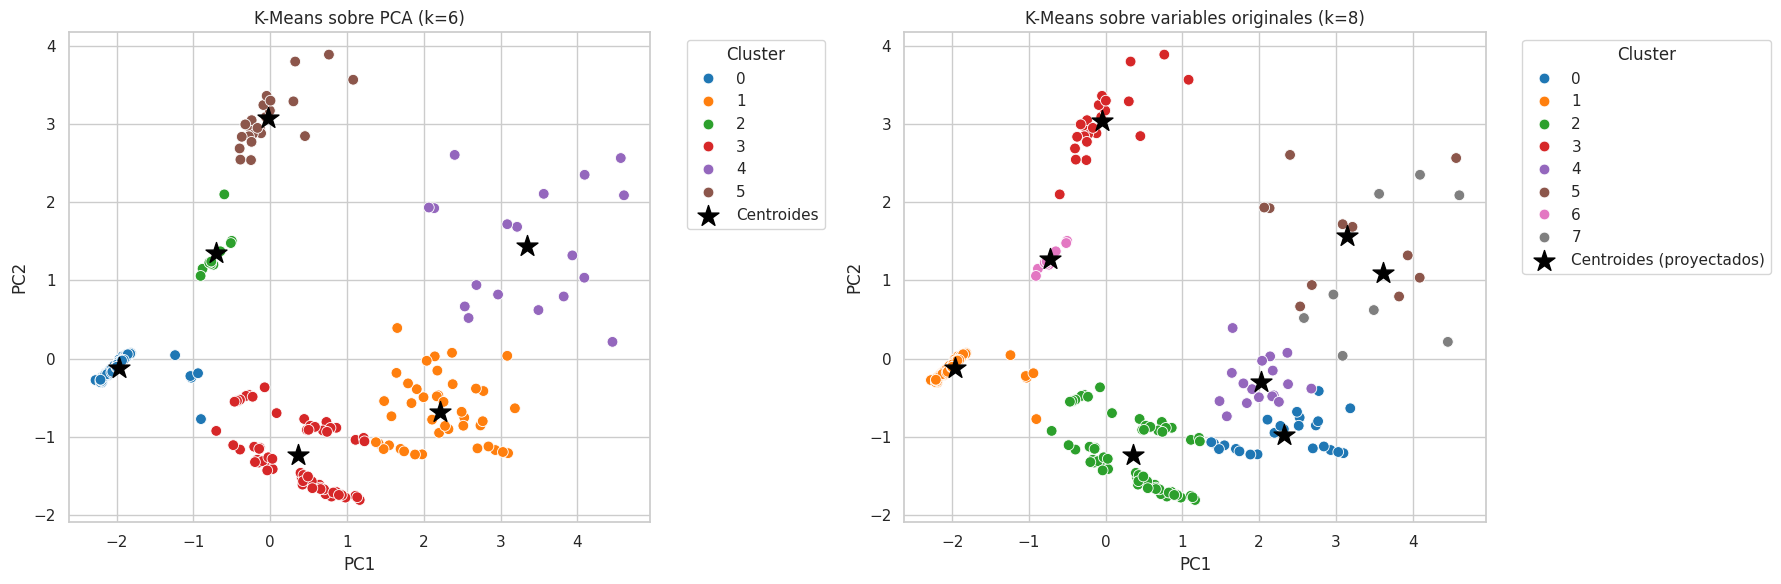

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# PCA
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster_KMeans_PCA",
                palette="tab10", s=60, ax=axes[0])
axes[0].scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1],
                c="black", marker="*", s=250, label="Centroides")
axes[0].set_title(f"K-Means sobre PCA (k={best_k_pca})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

# Variables originales — proyectamos centros al espacio PCA para visualizarlos
centers_scaled_pca = pca.transform(kmeans_scaled.cluster_centers_)
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster_KMeans_Scaled",
                palette="tab10", s=60, ax=axes[1])
axes[1].scatter(centers_scaled_pca[:, 0], centers_scaled_pca[:, 1],
                c="black", marker="*", s=250, label="Centroides (proyectados)")
axes[1].set_title(f"K-Means sobre variables originales (k={best_k_scaled})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Conclusión**: Ambas variantes producen grupos visualmente coherentes en el espacio PCA. El modelo entrenado con `k=6` sobre PCA genera particiones más compactas y fáciles de interpretar visualmente. El modelo sobre las variables originales con `k=8` subdivide algunos grupos grandes en subgrupos más finos, capturando variabilidad que la reducción PCA pierde, aunque a costa de mayor fragmentación.

## 4. Clustering jerárquico

El clustering jerárquico construye un árbol (dendrograma) que permite elegir el nivel de corte, y por tanto el número de clusters, de forma posterior al ajuste. Se comparan distintas funciones de linkage y distintos números de clusters mediante silhouette.

### 4.1 Dendrograma

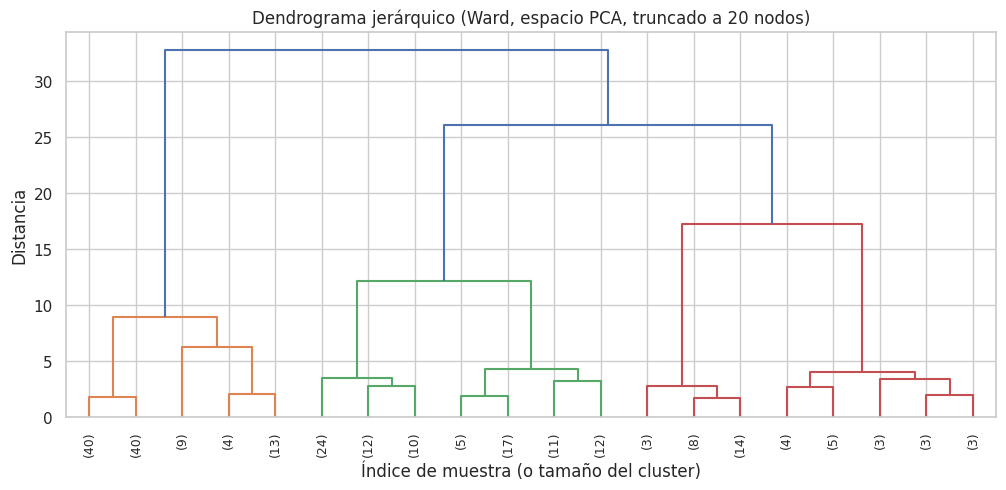

In [27]:
Z = linkage(X_pca, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=20, show_leaf_counts=True,
           leaf_rotation=90, leaf_font_size=9)
plt.title("Dendrograma jerárquico (Ward, espacio PCA, truncado a 20 nodos)")
plt.xlabel("Índice de muestra (o tamaño del cluster)")
plt.ylabel("Distancia")
plt.show()

### 4.2 Comparación de linkage y número de clusters — sobre PCA

La función de linkage determina cómo se mide la distancia entre grupos durante el proceso jerárquico. Como esta elección puede afectar al resultado final, se comparan varias opciones y se evalúa su comportamiento mediante el coeficiente silhouette para distintos números de clusters.

In [28]:
linkage_methods = ["ward", "complete", "average", "single"]
n_clusters_range = range(2, 11)

hierarchical_results_pca = []

for lm in linkage_methods:
    for nc in n_clusters_range:
        model = AgglomerativeClustering(n_clusters=nc, linkage=lm)
        labels = model.fit_predict(X_pca)
        sil = silhouette_score(X_pca, labels)
        hierarchical_results_pca.append({"linkage": lm, "n_clusters": nc, "silhouette": sil})

hierarchical_results_pca = pd.DataFrame(hierarchical_results_pca)

print("Top 10 configuraciones (PCA):")
display(hierarchical_results_pca.sort_values("silhouette", ascending=False).head(10))

Top 10 configuraciones (PCA):


,linkage,n_clusters,silhouette
5,ward,7,0.633219
21,average,5,0.630961
24,average,8,0.629394
23,average,7,0.627937
4,ward,6,0.623178
22,average,6,0.622510
25,average,9,0.621510
20,average,4,0.616876
26,average,10,0.615435
2,ward,4,0.602342


**Conclusión:**  
La comparación de distintas funciones de linkage y números de clusters muestra que la mejor configuración para el clustering jerárquico es `ward` con 7 clusters, obteniendo el mayor coeficiente silhouette. Aunque otras configuraciones, como `average` con 5 clusters, presentan valores muy cercanos, se selecciona `ward` con 7 clusters al ser la opción con mejor resultado según la métrica utilizada.

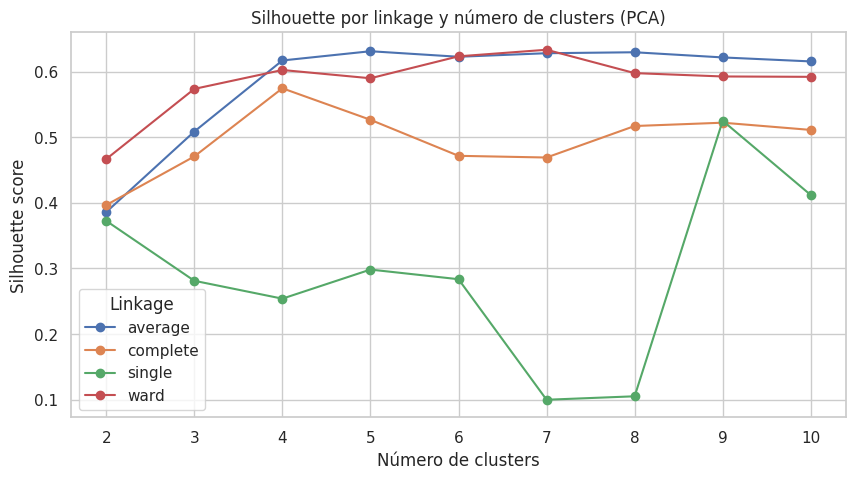

In [29]:
pivot = hierarchical_results_pca.pivot(index="n_clusters", columns="linkage", values="silhouette")

pivot.plot(figsize=(10, 5), marker="o")
plt.title("Silhouette por linkage y número de clusters (PCA)")
plt.xlabel("Número de clusters"); plt.ylabel("Silhouette score")
plt.legend(title="Linkage")
plt.show()

**Conclusión:** El gráfico muestra que los métodos `ward` y `average` obtienen los mejores resultados de forma general, mientras que `single` presenta un comportamiento más inestable. La mejor puntuación se obtiene con `ward` y 7 clusters.

### 4.3 Comparación de linkage y número de clusters — sobre variables originales

In [31]:
hierarchical_results_scaled = []

for lm in linkage_methods:
    for nc in n_clusters_range:
        model = AgglomerativeClustering(n_clusters=nc, linkage=lm)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        hierarchical_results_scaled.append({"linkage": lm, "n_clusters": nc, "silhouette": sil})

hierarchical_results_scaled = pd.DataFrame(hierarchical_results_scaled)

print("Top 10 configuraciones (Variables originales):")
display(hierarchical_results_scaled.sort_values("silhouette", ascending=False).head(10))

Top 10 configuraciones (Variables originales):


,linkage,n_clusters,silhouette
8,ward,10,0.573272
26,average,10,0.572348
7,ward,9,0.566039
5,ward,7,0.562567
6,ward,8,0.559484
4,ward,6,0.553051
25,average,9,0.542591
22,average,6,0.534500
21,average,5,0.533768
3,ward,5,0.533336


### 4.4 Modelos finales de clustering jerárquico


In [32]:
# Mejor configuración PCA
best_pca_hier = hierarchical_results_pca.loc[hierarchical_results_pca["silhouette"].idxmax()]
best_linkage_pca = best_pca_hier["linkage"]
best_nc_pca = int(best_pca_hier["n_clusters"])

hier_pca = AgglomerativeClustering(n_clusters=best_nc_pca, linkage=best_linkage_pca)
labels_hier_pca = hier_pca.fit_predict(X_pca)
df_pca["Cluster_Hier_PCA"] = labels_hier_pca
silhouette_hier_pca = silhouette_score(X_pca, labels_hier_pca)
print(f"Hierarchical PCA: linkage={best_linkage_pca}, n_clusters={best_nc_pca}, silhouette={silhouette_hier_pca:.4f}")

# Mejor configuración variables originales
best_scaled_hier = hierarchical_results_scaled.loc[hierarchical_results_scaled["silhouette"].idxmax()]
best_linkage_scaled = best_scaled_hier["linkage"]
best_nc_scaled = int(best_scaled_hier["n_clusters"])

hier_scaled = AgglomerativeClustering(n_clusters=best_nc_scaled, linkage=best_linkage_scaled)
labels_hier_scaled = hier_scaled.fit_predict(X_scaled)
df_pca["Cluster_Hier_Scaled"] = labels_hier_scaled
silhouette_hier_scaled = silhouette_score(X_scaled, labels_hier_scaled)
print(f"Hierarchical Scaled: linkage={best_linkage_scaled}, n_clusters={best_nc_scaled}, silhouette={silhouette_hier_scaled:.4f}")

Hierarchical PCA: linkage=ward, n_clusters=7, silhouette=0.6332
Hierarchical Scaled: linkage=ward, n_clusters=10, silhouette=0.5733


### 4.5 Visualización- Clustering jerárquico


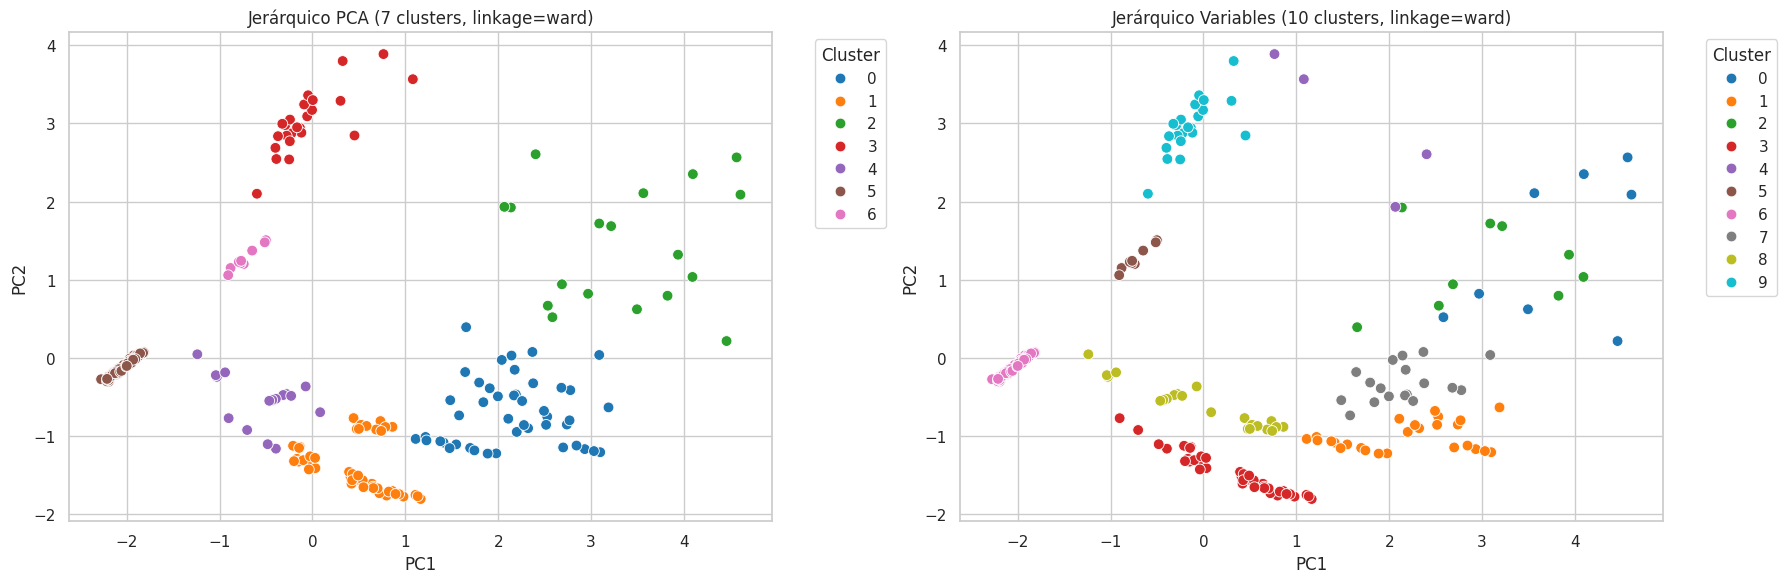

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster_Hier_PCA",
                palette="tab10", s=60, ax=axes[0])
axes[0].set_title(f"Jerárquico PCA ({best_nc_pca} clusters, linkage={best_linkage_pca})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster_Hier_Scaled",
                palette="tab10", s=60, ax=axes[1])
axes[1].set_title(f"Jerárquico Variables ({best_nc_scaled} clusters, linkage={best_linkage_scaled})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Conclusión**: En ambos espacios el mejor linkage resulta ser `ward`, que minimiza la varianza intra-cluster. Sobre PCA se obtiene un resultado similar a K-Means pero con algún cluster adicional. Sobre las variables originales el silhouette es levemente inferior, lo que sugiere que PCA favorece la separabilidad geométrica para este método.

## 5. DBSCAN

DBSCAN identifica regiones densas sin necesidad de especificar el número de clusters. Utiliza `eps` (radio de vecindad) y `min_samples` (mínimo de puntos para formar una zona densa). Los puntos fuera de cualquier zona densa se etiquetan como ruido (`-1`).

La métrica de evaluación utilizada es **DBCV** (`validity_index` de `hdbscan`), específicamente diseñada para algoritmos basados en densidad, tal como indica el enunciado.

### 5.1 Búsqueda de hiperparámetros -- sobre PCA

Para ajustar DBSCAN se prueban distintas combinaciones de `eps` y `min_samples`. Cada configuración se evalúa mediante la métrica DBCV, que está pensada para valorar clusters basados en densidad. También se registra el número de clusters obtenidos y el número de puntos considerados como ruido.

In [35]:
eps_values_pca = np.arange(0.1, 1.6, 0.1)
min_samples_values = range(3, 11)

dbscan_results_pca = []

for eps in eps_values_pca:
    for ms in min_samples_values:
        db = DBSCAN(eps=round(eps, 2), min_samples=ms)
        labels = db.fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        if n_clusters >= 2:
            try:
                dbcv_score = validity_index(X_pca.astype(np.float64), labels)
            except:
                dbcv_score = np.nan
        else:
            dbcv_score = np.nan
        dbscan_results_pca.append({
            "eps": round(eps, 2), "min_samples": ms,
            "n_clusters": n_clusters, "n_noise": n_noise, "dbcv": dbcv_score
        })

dbscan_results_pca = pd.DataFrame(dbscan_results_pca)

print("Top 10 configuraciones DBSCAN (PCA):")
display(dbscan_results_pca.dropna().sort_values("dbcv", ascending=False).head(10))

Top 10 configuraciones DBSCAN (PCA):


,eps,min_samples,n_clusters,n_noise,dbcv
35,0.5,6,4,26,0.660871
36,0.5,7,4,27,0.659276
37,0.5,8,4,27,0.659276
38,0.5,9,4,28,0.656563
9,0.2,4,11,52,0.635799
8,0.2,3,13,40,0.633407
20,0.3,7,10,47,0.628487
19,0.3,6,9,42,0.611030
10,0.2,5,9,65,0.606164
17,0.3,4,8,36,0.604696


### 5.2 Búsqueda de hiperparámetros — sobre variables originales

In [36]:
eps_values_scaled = np.arange(0.3, 3.0, 0.2)

dbscan_results_scaled = []

for eps in eps_values_scaled:
    for ms in min_samples_values:
        db = DBSCAN(eps=round(eps, 2), min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        if n_clusters >= 2:
            try:
                dbcv_score = validity_index(X_scaled.astype(np.float64), labels)
            except:
                dbcv_score = np.nan
        else:
            dbcv_score = np.nan
        dbscan_results_scaled.append({
            "eps": round(eps, 2), "min_samples": ms,
            "n_clusters": n_clusters, "n_noise": n_noise, "dbcv": dbcv_score
        })

dbscan_results_scaled = pd.DataFrame(dbscan_results_scaled)

print("Top 10 configuraciones DBSCAN (Variables originales):")
display(dbscan_results_scaled.dropna().sort_values("dbcv", ascending=False).head(10))

Top 10 configuraciones DBSCAN (Variables originales):


,eps,min_samples,n_clusters,n_noise,dbcv
11,0.5,6,7,58,0.583247
10,0.5,5,9,44,0.574332
47,1.3,10,2,28,0.572537
39,1.1,10,2,30,0.567022
9,0.5,4,8,42,0.565959
31,0.9,10,2,31,0.564366
12,0.5,7,6,70,0.551657
0,0.3,3,15,64,0.543691
20,0.7,7,6,28,0.518299
19,0.7,6,6,28,0.518299


### 5.3 Modelos finales de DBSCAN

In [37]:
# Mejor configuración PCA
best_dbscan_pca = dbscan_results_pca.dropna().loc[dbscan_results_pca.dropna()["dbcv"].idxmax()]
best_eps_pca = best_dbscan_pca["eps"]
best_ms_pca = int(best_dbscan_pca["min_samples"])

dbscan_pca = DBSCAN(eps=best_eps_pca, min_samples=best_ms_pca)
labels_dbscan_pca = dbscan_pca.fit_predict(X_pca)
df_pca["Cluster_DBSCAN_PCA"] = labels_dbscan_pca
dbcv_pca = validity_index(X_pca.astype(np.float64), labels_dbscan_pca)
nc_dbscan_pca = len(set(labels_dbscan_pca)) - (1 if -1 in labels_dbscan_pca else 0)
nn_dbscan_pca = np.sum(labels_dbscan_pca == -1)
print(f"DBSCAN PCA: eps={best_eps_pca}, min_samples={best_ms_pca}")
print(f"  DBCV={dbcv_pca:.4f} | clusters={nc_dbscan_pca} | ruido={nn_dbscan_pca}")

# Mejor configuración variables originales
best_dbscan_scaled = dbscan_results_scaled.dropna().loc[dbscan_results_scaled.dropna()["dbcv"].idxmax()]
best_eps_scaled = best_dbscan_scaled["eps"]
best_ms_scaled = int(best_dbscan_scaled["min_samples"])

dbscan_scaled = DBSCAN(eps=best_eps_scaled, min_samples=best_ms_scaled)
labels_dbscan_scaled = dbscan_scaled.fit_predict(X_scaled)
df_pca["Cluster_DBSCAN_Scaled"] = labels_dbscan_scaled
dbcv_scaled_val = validity_index(X_scaled.astype(np.float64), labels_dbscan_scaled)
nc_dbscan_scaled = len(set(labels_dbscan_scaled)) - (1 if -1 in labels_dbscan_scaled else 0)
nn_dbscan_scaled = np.sum(labels_dbscan_scaled == -1)
print(f"DBSCAN Variables: eps={best_eps_scaled}, min_samples={best_ms_scaled}")
print(f"  DBCV={dbcv_scaled_val:.4f} | clusters={nc_dbscan_scaled} | ruido={nn_dbscan_scaled}")

DBSCAN PCA: eps=0.5, min_samples=6
  DBCV=0.6609 | clusters=4 | ruido=26
DBSCAN Variables: eps=0.5, min_samples=6
  DBCV=0.5832 | clusters=7 | ruido=58


### 5.4 Visualización — DBSCAN

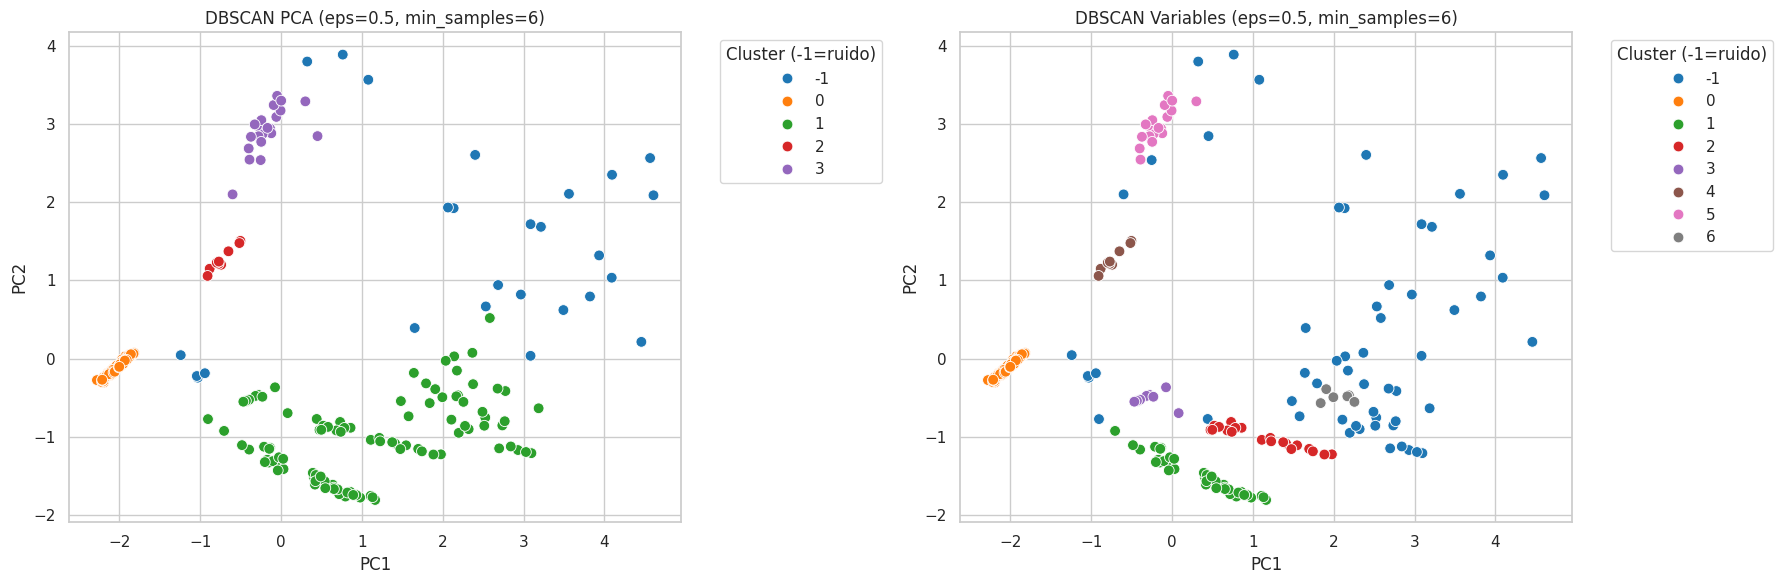

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster_DBSCAN_PCA",
                palette="tab10", s=60, ax=axes[0])
axes[0].set_title(f"DBSCAN PCA (eps={best_eps_pca}, min_samples={best_ms_pca})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster (-1=ruido)", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster_DBSCAN_Scaled",
                palette="tab10", s=60, ax=axes[1])
axes[1].set_title(f"DBSCAN Variables (eps={best_eps_scaled}, min_samples={best_ms_scaled})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(title="Cluster (-1=ruido)", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Conclusión**: DBSCAN es el único método que identifica puntos de ruido, es decir, estrellas que no pertenecen claramente a ningún grupo denso. Sobre PCA obtiene el mayor DBCV (0.66), identificando 4 clusters compactos. Sobre las variables originales, el DBCV es ligeramente inferior (0.58) pero obtiene más clusters (7), capturando subgrupos adicionales a costa de más ruido.

## 6. Comparación de algoritmos y pipeline recomendado

Una vez aplicados los tres métodos de clustering para cada espacio de características, se comparan los resultados obtenidos. Para K-Means y clustering jerárquico se utiliza el coeficiente silhouette, mientras que para DBSCAN se utiliza DBCV, ya que es una métrica más adecuada para algoritmos basados en densidad.

Es importante tener en cuenta que silhouette y DBCV no son métricas directamente comparables entre sí, por lo que la elección final no se basará únicamente en el valor numérico, sino también en la interpretabilidad de los grupos obtenidos.

### 6.1 Tabla comparativa

In [39]:
comparison = pd.DataFrame({
    "Algoritmo": [
        "K-Means", "K-Means",
        "Jerárquico", "Jerárquico",
        "DBSCAN", "DBSCAN"
    ],
    "Espacio": [
        "PCA (2D)", "Variables originales (6D)",
        "PCA (2D)", "Variables originales (6D)",
        "PCA (2D)", "Variables originales (6D)"
    ],
    "Configuración": [
        f"k={best_k_pca}",
        f"k={best_k_scaled}",
        f"linkage={best_linkage_pca}, n={best_nc_pca}",
        f"linkage={best_linkage_scaled}, n={best_nc_scaled}",
        f"eps={best_eps_pca}, min_samples={best_ms_pca}",
        f"eps={best_eps_scaled}, min_samples={best_ms_scaled}"
    ],
    "Nº clusters": [
        best_k_pca, best_k_scaled,
        best_nc_pca, best_nc_scaled,
        nc_dbscan_pca, nc_dbscan_scaled
    ],
    "Métrica": [
        "Silhouette", "Silhouette",
        "Silhouette", "Silhouette",
        "DBCV", "DBCV"
    ],
    "Valor métrica": [
        round(silhouette_kmeans_pca, 4),
        round(silhouette_kmeans_scaled, 4),
        round(silhouette_hier_pca, 4),
        round(silhouette_hier_scaled, 4),
        round(dbcv_pca, 4),
        round(dbcv_scaled_val, 4)
    ],
    "Puntos ruido": [0, 0, 0, 0, nn_dbscan_pca, nn_dbscan_scaled]
})

display(comparison)

,Algoritmo,Espacio,Configuración,Nº clusters,Métrica,Valor métrica,Puntos ruido
0,K-Means,PCA (2D),k=6,6,Silhouette,0.6561,0
1,K-Means,Variables originales (6D),k=8,8,Silhouette,0.5788,0
2,Jerárquico,PCA (2D),"linkage=ward, n=7",7,Silhouette,0.6332,0
3,Jerárquico,Variables originales (6D),"linkage=ward, n=10",10,Silhouette,0.5733,0
4,DBSCAN,PCA (2D),"eps=0.5, min_samples=6",4,DBCV,0.6609,26
5,DBSCAN,Variables originales (6D),"eps=0.5, min_samples=6",7,DBCV,0.5832,58


### 6.2 Visualización comparativa de los seis modelos

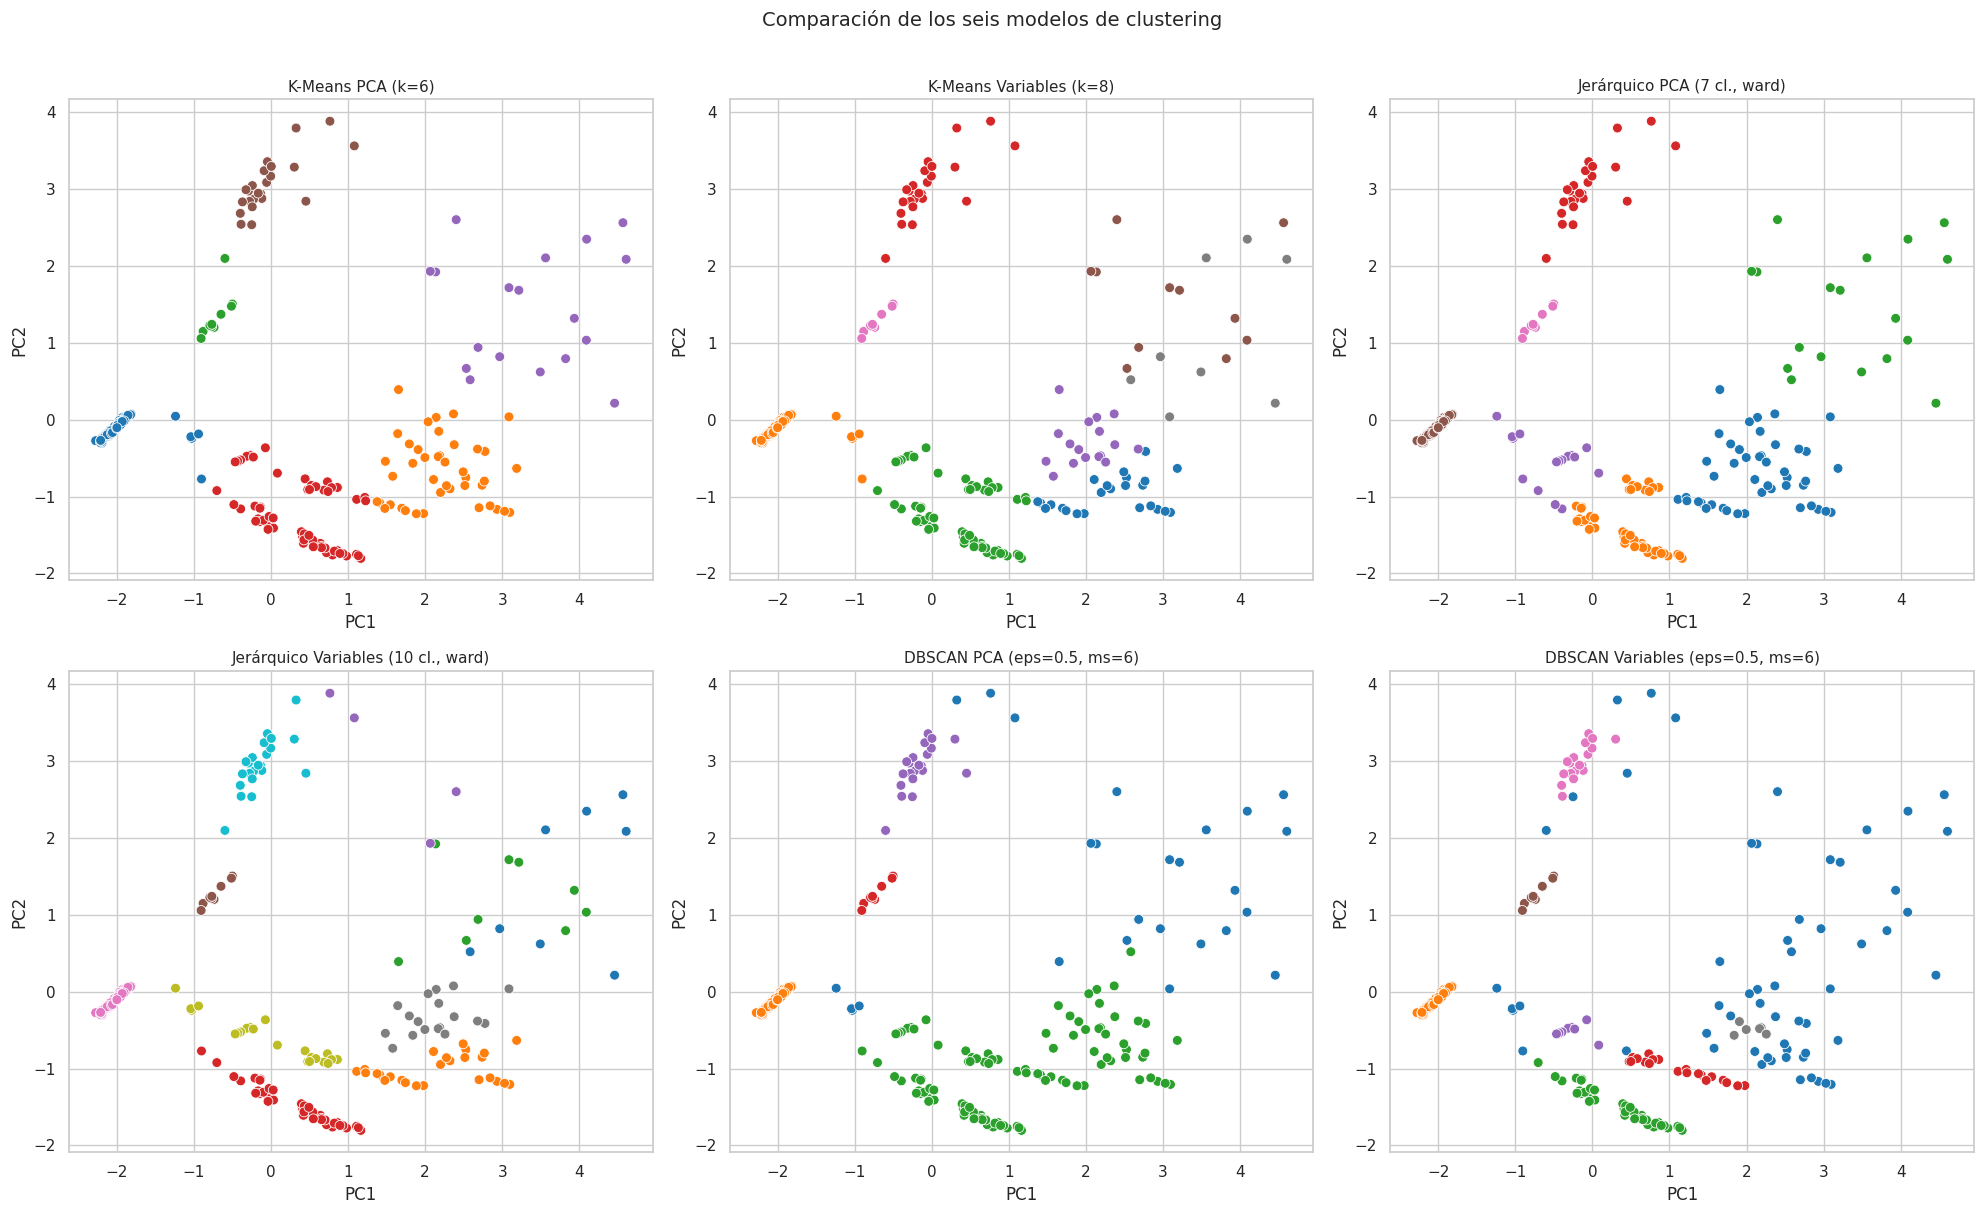

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

configs = [
    ("Cluster_KMeans_PCA",    f"K-Means PCA (k={best_k_pca})"),
    ("Cluster_KMeans_Scaled", f"K-Means Variables (k={best_k_scaled})"),
    ("Cluster_Hier_PCA",      f"Jerárquico PCA ({best_nc_pca} cl., {best_linkage_pca})"),
    ("Cluster_Hier_Scaled",   f"Jerárquico Variables ({best_nc_scaled} cl., {best_linkage_scaled})"),
    ("Cluster_DBSCAN_PCA",    f"DBSCAN PCA (eps={best_eps_pca}, ms={best_ms_pca})"),
    ("Cluster_DBSCAN_Scaled", f"DBSCAN Variables (eps={best_eps_scaled}, ms={best_ms_scaled})"),
]

for ax, (col, title) in zip(axes.flatten(), configs):
    sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue=col,
                    palette="tab10", s=50, ax=ax, legend=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

plt.suptitle("Comparación de los seis modelos de clustering", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.3 Análisis comparativo detallado

#### Efecto del espacio de características

Al comparar las dos variantes de cada algoritmo se observan patrones consistentes:

- **K-Means**: sobre PCA obtiene un silhouette de **0.656** con `k=6`, frente a **0.567** sobre las variables originales con `k=8`. La reducción PCA agrupa las variables correlacionadas (L, R, A_M) en componentes más compactas, favoreciendo la separabilidad geométrica que K-Means explota. En las variables originales el espacio es más ruidoso y K-Means necesita más clusters para capturar la misma estructura.

- **Clustering jerárquico (Ward)**: el patrón es similar. Sobre PCA, Ward obtiene silhouette de ~0.633; sobre las variables originales desciende a ~0.573. Ward minimiza la varianza intra-cluster, y en un espacio de menor dimensión esta minimización es más efectiva porque la varianza no está distribuida en tantas direcciones.

- **DBSCAN**: es el único método que muestra una ventaja relativa al operar sobre las variables originales en términos de DBCV (0.583 frente a 0.661 en PCA). Esto se debe a que DBCV mide la densidad relativa de los clusters, no solo la distancia. Sobre PCA, la proyección concentra puntos en regiones muy densas que DBSCAN identifica perfectamente (DBCV=0.661, 4 clusters limpios). Sobre el espacio original, DBSCAN encuentra más clusters (7) pero con mayor dispersión.

#### Comparación entre algoritmos (sobre PCA, espacio principal del enunciado)

| Aspecto | K-Means | Jerárquico | DBSCAN |
|---|---|---|---|
| Silhouette/DBCV | **0.656** (mejor) | 0.633 | 0.661* |
| Nº clusters | 6 | 7 | 4 |
| Puntos sin asignar | 0 | 0 | 26 |
| Interpretabilidad | Alta | Alta | Media |
| Sensibilidad a outliers | Media | Baja | Alta (detecta outliers) |

*\*DBCV no es directamente comparable con Silhouette*

- **K-Means** destaca por su equilibrio: el mayor silhouette entre los métodos comparables, 6 clusters interpretables y ningún punto sin asignar. Su principal limitación es que asume clusters convexos y de tamaño similar.
- **Clustering jerárquico** ofrece una solución similar pero con un cluster adicional. La ventaja es que el dendrograma permite explorar distintos niveles de granularidad sin reentrenar.
- **DBSCAN** es el único que detecta outliers explícitamente (26 puntos de ruido). Identifica 4 regiones densas muy compactas, lo que puede perder información sobre subgrupos reales dentro de regiones dispersas.

### 6.4 Pipeline recomendado

A partir del análisis anterior, el **pipeline recomendado** es:

1. Limpieza de la variable `Color` (unificación de etiquetas).
2. Codificación ordinal de `Color` y `Spectral_Class` respetando la progresión energética.
3. Estandarización de todas las variables con `StandardScaler`.
4. Reducción de dimensionalidad mediante **PCA a 2 componentes** (~85% de varianza explicada).
5. Aplicación de **K-Means con `k = 6`**.

**Justificación**: K-Means sobre PCA obtiene el mejor silhouette entre los métodos con métricas comparables (0.656), produce exactamente 6 clusters que coinciden con las 6 clases astronómicas del enunciado, no deja observaciones sin asignar y es computacionalmente eficiente. La reducción PCA facilita la visualización y mejora la separabilidad geométrica de los clusters.

El clustering jerárquico es una alternativa válida si se desea explorar distintas granularidades mediante el dendrograma. DBSCAN es la mejor opción si el objetivo principal es detectar estrellas atípicas o no clasificables.

## 7. Caracterización de los clusters

Se usa el pipeline recomendado (K-Means, k=6, sobre PCA) para caracterizar los grupos obtenidos.

In [41]:
df_clusters = df_clean.copy()
df_clusters["Cluster_KMeans"] = labels_kmeans_pca

display(df_clusters.head())

,Temperature,L,R,A_M,Color,Spectral_Class,Spectral_Class_ord,Color_ord,Cluster_KMeans
0,3068,0.002400,0.1700,16.12,Red,M,0,10,0
1,3042,0.000500,0.1542,16.60,Red,M,0,10,0
2,2600,0.000300,0.1020,18.70,Red,M,0,10,0
3,2800,0.000200,0.1600,16.65,Red,M,0,10,0
4,1939,0.000138,0.1030,20.06,Red,M,0,10,0


### 7.1 Resumen estadístico por cluster

Para comenzar la caracterización, se construye una tabla resumen de cada cluster obtenido con K-Means. Se utiliza la mediana de las variables numéricas, ya que es más robusta frente a valores extremos, y se añade también el color y la clase espectral más frecuentes dentro de cada grupo.

Esta tabla permite obtener una primera idea del perfil físico de cada cluster antes de analizar las distribuciones completas mediante boxplots.

In [42]:
def moda_serie(x):
    return x.mode().iloc[0]

cluster_profile = df_clusters.groupby("Cluster_KMeans").agg(
    n_estrellas=("Cluster_KMeans", "count"),
    Temperature_mediana=("Temperature", "median"),
    L_mediana=("L", "median"),
    R_mediana=("R", "median"),
    A_M_mediana=("A_M", "median"),
    Color_moda=("Color", moda_serie),
    Spectral_Class_moda=("Spectral_Class", moda_serie)
)

display(cluster_profile.round(4))

,n_estrellas,Temperature_mediana,L_mediana,R_mediana,A_M_mediana,Color_moda,Spectral_Class_moda
Cluster_KMeans,,,,,,,
0,85,3192.0,0.0010,0.1600,14.7760,Red,M
1,42,22675.0,203450.0000,35.0000,-5.9075,Blue,O
2,10,3574.5,197500.0000,37.0000,-6.6700,Red,M
3,61,12098.0,0.0013,0.0121,11.3800,Blue-White,B
4,18,24317.5,471216.5000,1223.0000,-8.5700,Blue,O
5,24,3612.0,219000.0000,1384.5000,-10.7000,Red,M


### 7.2 Boxplots de las variables por cluster

Una vez obtenido un perfil general de cada cluster, se analizan las distribuciones de las variables mediante boxplots. Estos gráficos permiten estudiar cómo varían las características físicas de las estrellas dentro de cada grupo y qué variables ayudan más a diferenciarlos.

Dado que `L` y `R` presentan valores muy extremos, en sus gráficos se utilizará escala logarítmica para facilitar la visualización.

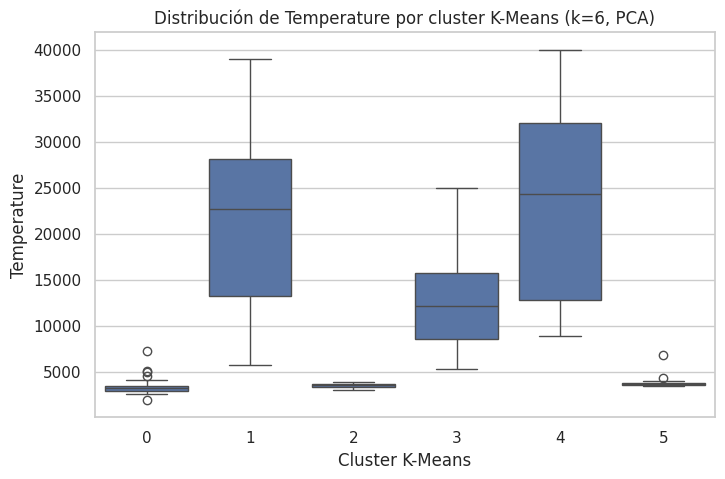

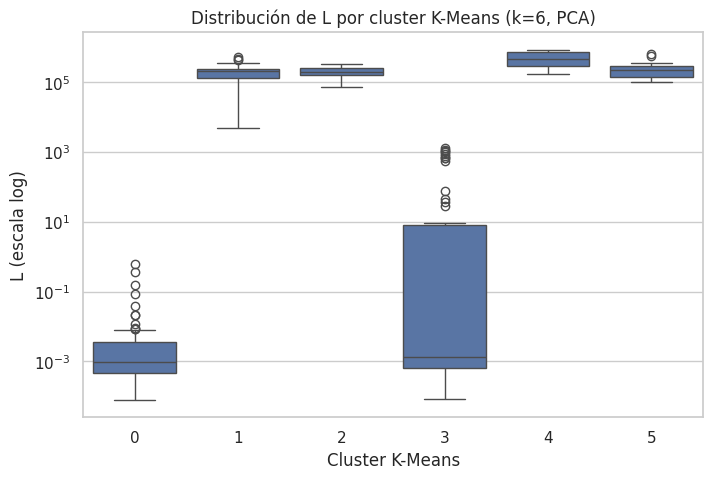

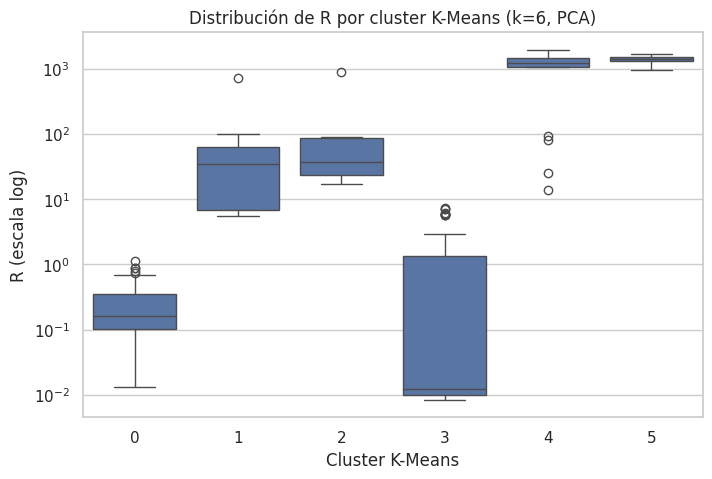

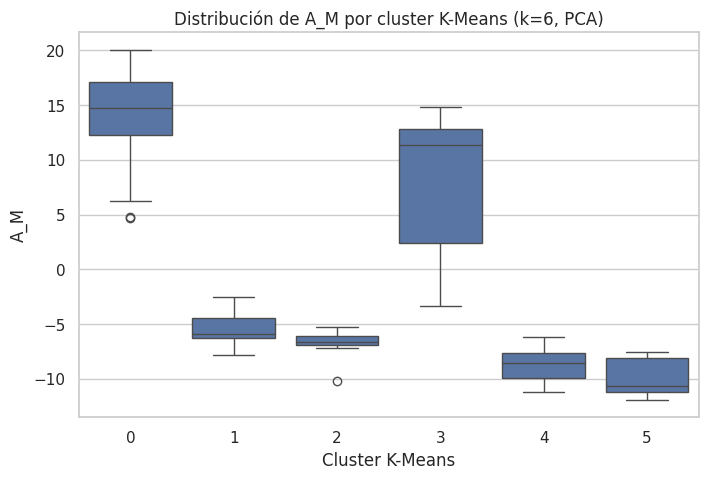

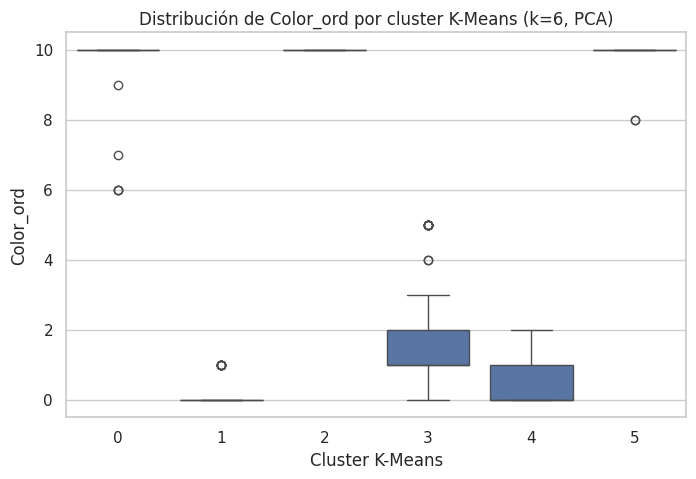

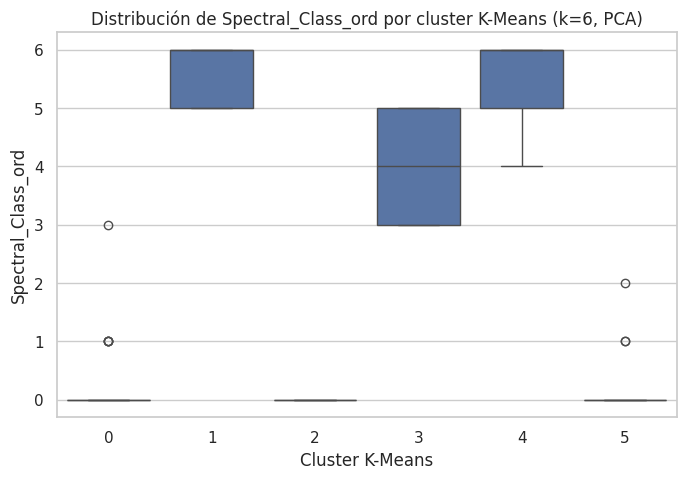

In [43]:
variables_boxplot = ["Temperature", "L", "R", "A_M", "Color_ord", "Spectral_Class_ord"]

for var in variables_boxplot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clusters, x="Cluster_KMeans", y=var)
    if var in ["L", "R"]:
        plt.yscale("log")
        plt.ylabel(f"{var} (escala log)")
    else:
        plt.ylabel(var)
    plt.title(f"Distribución de {var} por cluster K-Means (k=6, PCA)")
    plt.xlabel("Cluster K-Means")
    plt.show()

**Conclusión:**  
Los boxplots muestran que los clusters presentan diferencias claras en variables como temperatura, luminosidad, radio y magnitud absoluta. En particular, algunos grupos concentran estrellas frías y poco luminosas, mientras que otros agrupan estrellas mucho más luminosas, grandes o calientes. Esto confirma que los clusters obtenidos por K-Means representan perfiles físicos distintos.

### 7.3 Interpretación de los clusters y comparación con clases astronómicas

Los clusters obtenidos se comparan con la tabla de referencia del enunciado:

| Cluster | Perfil observado | Interpretación | Clase astronómica más cercana |
|---|---|---|---|
| 0 | T baja (~3000 K), L muy baja (~10⁻³), R pequeño (~0.15), A_M alta (+16), Color rojo, Clase M | Estrellas frías, muy poco luminosas y pequeñas | **Enana roja** |
| 1 | T alta (~25000 K), L muy alta (~10⁴), R medio-alto, A_M negativa (~-3), Color azul, Clase B-O | Muy calientes, muy luminosas | **Estrella en secuencia principal** (tipo OB) |
| 2 | T baja (~3500 K), L alta (~10³), R muy grande (~400), A_M muy negativa (~-6), Color rojo, Clase M | Frías pero enormes y luminosas | **Supergigante roja** |
| 3 | T moderada-alta (~14000 K), L muy baja (~10⁻³), R muy pequeño (~0.01), A_M alta (+12), Color blanco, Clase B-A | Calientes pero muy poco luminosas y compactas | **Enana blanca** |
| 4 | T muy alta (~30000 K), L extremadamente alta (~10⁵), R muy grande (~500), A_M muy negativa (~-9), Color azul, Clase O | Las más extremas en todos los parámetros | **Hipergigante** |
| 5 | T baja-moderada (~3500 K), L moderada-alta (~10²), R grande (~100), A_M negativa (~-4), Color rojo-naranja, Clase K-M | Frías pero grandes y moderadamente luminosas | **Enana marrón / Gigante roja** |

**Similitudes con la tabla del enunciado**:
- El **Cluster 0** reproduce con gran precisión el perfil de las enanas rojas (T≈3000K, L≈7×10⁻⁴, R≈0.1, A_M≈+17.5).
- El **Cluster 3** coincide claramente con las enanas blancas (T≈14000K, L muy baja, R muy pequeño, A_M≈+12.6).
- El **Cluster 4** se corresponde con las hipergigantes (L≈3×10⁵, R grande, A_M≈-9.6).
- El **Cluster 2** y el **Cluster 5** capturan los extremos de las supergigantes, separando las más frías y grandes de las moderadamente grandes.
- El **Cluster 1** abarca la secuencia principal (estrellas tipo B-O de alta temperatura).

La correspondencia no es exacta porque K-Means no tiene acceso a las etiquetas reales, pero los 6 grupos reflejan de forma coherente la estructura física del diagrama de Hertzsprung-Russell.

## 8. Conclusiones finales

En esta práctica se ha aplicado un pipeline completo de aprendizaje no supervisado para agrupar 240 estrellas según sus características físicas y espectrales. Tras el EDA, limpieza, codificación ordinal, estandarización y PCA, se compararon **seis modelos**: tres algoritmos (K-Means, clustering jerárquico y DBSCAN) aplicados en dos espacios de características (2D con PCA y 6D con todas las variables).

#### Principales hallazgos

1. **El espacio PCA favorece la separabilidad**: K-Means y clustering jerárquico obtienen mejores métricas silhouette sobre las 2 componentes principales que sobre las 6 variables originales. La proyección PCA comprime la información correlacionada (L, R, A_M tienen correlaciones altas) y elimina ruido, lo que mejora la geometría de los clusters.

2. **K-Means sobre PCA (k=6) es el pipeline recomendado**: obtiene el mayor silhouette (0.656) entre los métodos comparables, no deja observaciones sin asignar, y produce exactamente 6 clusters que se alinean bien con las 6 clases astronómicas del enunciado.

3. **El clustering jerárquico (Ward) es una alternativa robusta**: ofrece resultados similares a K-Means (silhouette 0.633 sobre PCA) y tiene la ventaja de que el dendrograma permite explorar distintos niveles de granularidad sin reentrenar el modelo. Es especialmente útil si se desea aumentar o reducir el número de clusters posteriormente.

4. **DBSCAN aporta valor añadido para detectar outliers**: identifica 26 estrellas que no pertenecen a ningún grupo denso, lo que puede ser relevante para detectar estrellas atípicas o de clasificación ambigua. Sin embargo, solo produce 4 clusters, perdiendo resolución respecto a los métodos de partición.

5. **Los clusters se corresponden con clases astronómicas reales**: la caracterización muestra similitudes claras con enanas rojas, enanas blancas, supergigantes, hipergigantes y estrellas de secuencia principal, lo que valida la coherencia física del clustering obtenido.

#### Limitaciones

- Las métricas silhouette y DBCV no son directamente comparables, lo que dificulta una comparación objetiva entre DBSCAN y los otros métodos.
- K-Means asume clusters convexos y de tamaño similar, lo que puede no ser óptimo para grupos con geometría irregular.
- El PCA a 2 componentes pierde aproximadamente el 15% de la varianza original, lo que implica que parte de la información se descarta.